# 04 – Early-2026 Out-of-Sample Validation of NVI

## 1. Objective

This notebook evaluates the **Narrative Volatility Index (NVI)** in an out-of-sample setting.

The main NVI framework was constructed using country-level volatility components. In this notebook, **2025** is used as the baseline period, and **early-2026 observations** are evaluated using the same baseline normalization parameters.

Because the 2026 data covers only the **first three months of the year**, the results should be interpreted as an **early-2026 comparison** rather than a full-year validation.

The main objectives are:

- recomputing rolling volatility across the full available timeline,
- extracting comparable **2025** and **early-2026** country-level snapshots,
- using **2025** as the baseline normalization period,
- calculating NVI values for 2025 and 2026 on the same scale,
- measuring changes in NVI between 2025 and early 2026,
- validating the recalculated 2025 NVI against the main NVI table,
- identifying countries with increasing or decreasing narrative volatility,
- analyzing regime shifts between 2025 and early 2026,
- examining whether major conflict environments during early 2026, especially the **Iran–Israel–Gulf escalation**, are reflected in NVI changes.

This notebook does **not** claim that wars or conflicts directly caused the observed NVI changes. Instead, it evaluates whether NVI shifts are **descriptively aligned** with major conflict-related developments during the same period.

## 2. Setup and Data Source

The analysis uses the same DuckDB database created in the previous notebooks. The input data comes from the country-month narrative indicators and volatility components generated during the NVI construction process.

The required Python libraries are imported first.

In [32]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("../data/intermediate/gdelt_main.db")

## 3. Recomputing Rolling Volatility on the Full Timeline

Rolling volatility is recomputed across the full available country-month timeline before extracting yearly snapshots.

This is important because rolling volatility depends on previous months. If the data were filtered too early, the rolling window for 2026 would lose historical context. Therefore, the rolling volatility calculation is performed first, and the 2025/2026 snapshots are extracted afterward.

In [33]:
# =========================
# 1. VOLATILITY (FULL DATA - NO FILTER)
# =========================

con.execute("""
CREATE OR REPLACE TABLE narrative_volatility AS
SELECT
    country,
    year_month,

    STDDEV(tone_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS tone_vol,

    STDDEV(goldstein_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS goldstein_vol,

    STDDEV(quad_entropy) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS entropy_vol

FROM narrative_country_month;
""")

## 4. Creating 2025 and 2026 Snapshots

After rolling volatility is computed, country-level snapshots are created for the comparison periods.

The 2025 snapshot represents the baseline period. The 2026 snapshot represents the out-of-sample period. Both snapshots are constructed for the same set of countries to ensure that the comparison is consistent.

In [34]:
# =========================
# 2. FILTER (ONLY HERE!)
# =========================

filtered_2025 = con.execute("""
SELECT country,
       SUM(event_count) AS total_events,
       MIN(event_count) AS min_monthly_events
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
GROUP BY country
HAVING total_events >= 60
   AND min_monthly_events >= 10
""").fetchdf()

In [35]:
# =========================
# 3. SNAPSHOTS
# =========================

nvi_2025 = con.execute("""
SELECT v.country, v.tone_vol, v.goldstein_vol, v.entropy_vol
FROM narrative_volatility v
JOIN (
    SELECT country,
           SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month
    WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
    GROUP BY country
) e
ON v.country = e.country
WHERE v.year_month = DATE '2025-12-01'
AND e.total_events >= 60
AND e.min_monthly_events >= 10
""").fetchdf()

nvi_2026 = con.execute("""
SELECT v.country, v.tone_vol, v.goldstein_vol, v.entropy_vol
FROM narrative_volatility v
JOIN (
    SELECT country,
           SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month
    WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
    GROUP BY country
) e
ON v.country = e.country
WHERE v.year_month = DATE '2026-03-01'
AND e.total_events >= 60
AND e.min_monthly_events >= 10
""").fetchdf()

In [36]:
# =========================
# 4. RENAME
# =========================

nvi_2025 = nvi_2025.rename(columns={
    "tone_vol": "tone_2025",
    "goldstein_vol": "goldstein_2025",
    "entropy_vol": "entropy_2025"
})

nvi_2026 = nvi_2026.rename(columns={
    "tone_vol": "tone_2026",
    "goldstein_vol": "goldstein_2026",
    "entropy_vol": "entropy_2026"
})

In [37]:
# =========================
# 5. MERGE (SAME COUNTRIES)
# =========================

merged = nvi_2025.merge(nvi_2026, on="country", how="inner")

print("Countries used:", merged.shape[0])

Countries used: 211


## 5. Baseline Normalization

The NVI components are normalized using only the **2025 baseline distribution**. This means that the mean and standard deviation of each volatility component are estimated from the 2025 snapshot.

The same baseline parameters are then applied to both 2025 and 2026. This allows the 2026 NVI values to be interpreted relative to the 2025 baseline scale.

This step is essential for out-of-sample validation because it avoids recalculating the scale separately for 2026.

In [38]:
# =========================
# 6. BASELINE NORMALIZATION (2025 ONLY)
# =========================

mu_tone = merged["tone_2025"].mean()
std_tone = merged["tone_2025"].std()

mu_gold = merged["goldstein_2025"].mean()
std_gold = merged["goldstein_2025"].std()

mu_entropy = merged["entropy_2025"].mean()
std_entropy = merged["entropy_2025"].std()

## 6. Computing NVI on the 2025 Baseline Scale

After estimating the baseline normalization parameters from 2025, NVI values are computed for both years using the same scale.

The 2025 NVI represents the baseline score, while the 2026 NVI shows how each country appears when evaluated against the 2025 volatility structure.

In [39]:
# =========================
# 7. NVI 2025 (BASELINE EXACT)
# =========================

merged["z_tone_2025"] = (merged["tone_2025"] - mu_tone) / std_tone
merged["z_gold_2025"] = (merged["goldstein_2025"] - mu_gold) / std_gold
merged["z_entropy_2025"] = (merged["entropy_2025"] - mu_entropy) / std_entropy

merged["NVI_2025"] = (
    merged["z_tone_2025"] +
    merged["z_gold_2025"] +
    merged["z_entropy_2025"]
)

In [40]:
# =========================
# 8. NVI 2026 (SAME SCALE)
# =========================

merged["z_tone_2026"] = (merged["tone_2026"] - mu_tone) / std_tone
merged["z_gold_2026"] = (merged["goldstein_2026"] - mu_gold) / std_gold
merged["z_entropy_2026"] = (merged["entropy_2026"] - mu_entropy) / std_entropy

merged["NVI_2026"] = (
    merged["z_tone_2026"] +
    merged["z_gold_2026"] +
    merged["z_entropy_2026"]
)

## 7. Delta NVI Analysis

The change in narrative volatility is measured using the difference between 2026 and 2025 NVI values.

A positive `delta_NVI` indicates that a country's narrative volatility increased in 2026 relative to the 2025 baseline. A negative value indicates that narrative volatility decreased.

In [41]:
# =========================
# 9. DELTA NVI
# =========================

merged["delta_NVI"] = merged["NVI_2026"] - merged["NVI_2025"]

Countries with the largest positive `delta_NVI` represent cases where narrative volatility increased the most relative to the baseline. Countries with the largest negative `delta_NVI` represent cases where narrative volatility decreased the most.

## 8. Validation Against the Main NVI Table

The recalculated 2025 NVI is compared with the main NVI values from the previous notebook. This check verifies that the baseline recomputation is consistent with the original NVI construction.

A very small maximum difference indicates that the recomputed baseline NVI matches the original NVI values and that the out-of-sample validation pipeline is internally consistent.

In [42]:
# =========================
# 10. VALIDATION (CRITICAL)
# =========================

baseline = con.execute("""
SELECT country, NVI
FROM narrative_nvi
""").fetchdf()

test = baseline.merge(merged[["country","NVI_2025"]], on="country")

test["diff"] = test["NVI"] - test["NVI_2025"]

print("MAX DIFF (should be ~0):", test["diff"].abs().max())

MAX DIFF (should be ~0): 3.552713678800501e-15


The maximum difference is around \(10^{-15}\), which is effectively zero and reflects only floating-point precision differences. This confirms that the recalculated 2025 baseline NVI is consistent with the main NVI construction pipeline.

## 9. Distribution Shift Analysis

The distributions of 2025 and 2026 NVI values are compared to inspect whether the overall narrative volatility structure shifted between the baseline and evaluation periods.

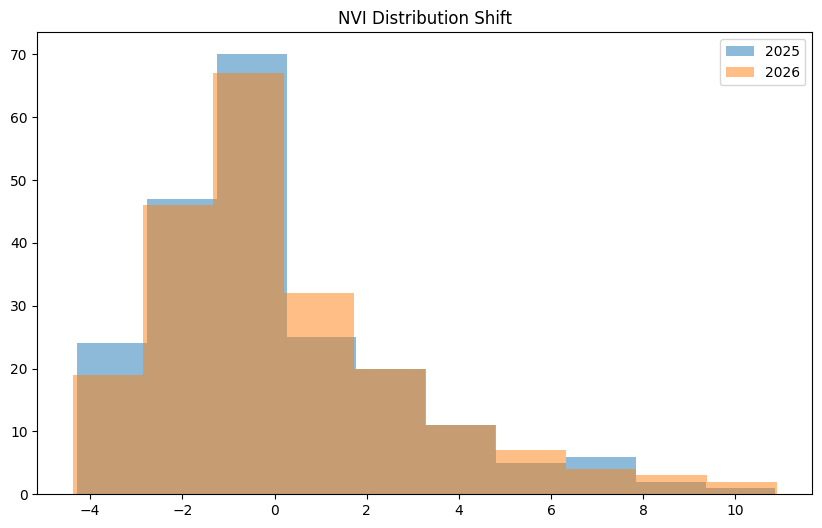

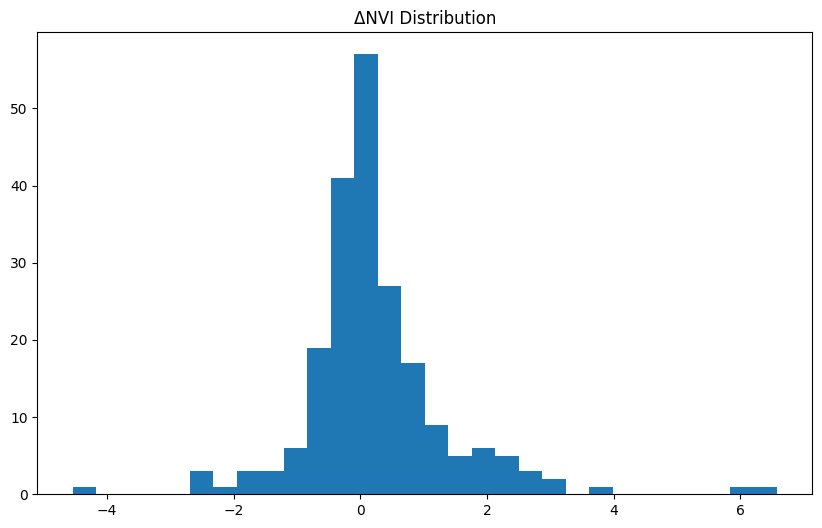

In [43]:
# =========================
# 11. PLOTS
# =========================

plt.figure(figsize=(10,6))
plt.hist(merged["NVI_2025"], alpha=0.5, label="2025")
plt.hist(merged["NVI_2026"], alpha=0.5, label="2026")
plt.legend()
plt.title("NVI Distribution Shift")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged["delta_NVI"], bins=30)
plt.title("ΔNVI Distribution")
plt.show()

## 10. Regime Shift Analysis

Countries are assigned to regimes based on the 2025 NVI distribution, and the same thresholds are applied to 2026 values. This allows regime changes to be interpreted relative to the baseline year.

The regime transition analysis shows whether countries moved from `Stable` to `Moderate`, from `Moderate` to `Shock`, or in the opposite direction between 2025 and 2026.

In [44]:
# =========================
# 12. REGIME SHIFT
# =========================

q25 = merged["NVI_2025"].quantile(0.25)
q75 = merged["NVI_2025"].quantile(0.75)

def regime(x):
    if x > q75:
        return "Shock"
    elif x < q25:
        return "Stable"
    else:
        return "Moderate"

merged["regime_2025"] = merged["NVI_2025"].apply(regime)
merged["regime_2026"] = merged["NVI_2026"].apply(regime)

merged["regime_change"] = merged["regime_2025"] + " → " + merged["regime_2026"]

In [45]:
top_positive_shifts = merged.sort_values("delta_NVI", ascending=False)[[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026",
    "regime_change"
]].head(10)

top_positive_shifts

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026,regime_change
10,BHR,-0.513215,6.067970,6.581186,Moderate,Shock,Moderate → Shock
14,KWT,-0.238648,5.732120,5.970768,Moderate,Shock,Moderate → Shock
22,ARE,-1.235715,2.645284,3.880999,Moderate,Shock,Moderate → Shock
147,IRQ,-2.688478,0.302389,2.990867,Stable,Moderate,Stable → Moderate
96,OMN,0.723203,3.646784,2.923581,Moderate,Shock,Moderate → Shock
19,SAU,-1.831909,0.949078,2.780987,Stable,Moderate,Stable → Moderate
169,QAT,0.113307,2.825710,2.712403,Moderate,Shock,Moderate → Shock
166,MHL,3.299954,5.893928,2.593974,Shock,Shock,Shock → Shock
44,AFG,-1.269015,1.112376,2.381391,Moderate,Shock,Moderate → Shock
199,IRN,-1.395491,0.910231,2.305722,Moderate,Moderate,Moderate → Moderate


In [46]:
top_negative_shifts = merged.sort_values("delta_NVI", ascending=True)[[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026",
    "regime_change"
]].head(10)

top_negative_shifts

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026,regime_change
17,RWA,3.666648,-0.874565,-4.541213,Shock,Moderate,Shock → Moderate
24,BDI,9.185717,6.752223,-2.433494,Shock,Shock,Shock → Shock
0,AGO,2.843177,0.421787,-2.421390,Shock,Moderate,Shock → Moderate
143,AIA,4.901758,2.527745,-2.374013,Shock,Shock,Shock → Shock
184,COD,2.293372,0.006936,-2.286435,Shock,Moderate,Shock → Moderate
70,KOR,-0.363373,-2.099879,-1.736506,Moderate,Stable,Moderate → Stable
170,SWE,-0.585665,-2.313156,-1.727491,Moderate,Stable,Moderate → Stable
127,SLV,0.382126,-1.226747,-1.608872,Moderate,Moderate,Moderate → Moderate
185,CRI,0.888709,-0.676416,-1.565125,Moderate,Moderate,Moderate → Moderate
40,SSD,-0.541221,-1.848295,-1.307073,Moderate,Stable,Moderate → Stable


In [47]:
regime_transition_summary = merged["regime_change"].value_counts().reset_index()
regime_transition_summary.columns = ["regime_change", "country_count"]

regime_transition_summary

,regime_change,country_count
0,Moderate → Moderate,84
1,Shock → Shock,49
2,Stable → Stable,42
3,Moderate → Shock,14
4,Stable → Moderate,11
5,Moderate → Stable,7
6,Shock → Moderate,4


The regime transition analysis shows how countries move across **Stable**, **Moderate**, and **Shock** categories when 2026 values are evaluated using the 2025 baseline thresholds.

A movement into the **Shock** regime indicates that a country’s narrative volatility increased enough to exceed the 2025 upper-threshold level. A movement into the **Stable** regime indicates a relative decrease in volatility compared with the 2025 baseline.

These transitions should be interpreted as **relative changes in narrative volatility**, not as direct evidence of conflict escalation or de-escalation.

## 11. Middle East and Gulf Case Analysis

This section focuses on selected Middle East and Gulf countries to inspect how NVI changed between 2025 and early 2026 within a politically salient regional subset.

The analysis is descriptive. It does not claim to explain the causes of geopolitical events; rather, it shows how the NVI framework can be used to compare changes in narrative volatility across selected countries.

### 11.1 Middle East and Gulf NVI Table

In [17]:
middle_east_gulf = [
    "TUR", "IRN", "IRQ", "SYR", "SAU", "ARE", "QAT", "KWT", 
    "OMN", "BHR", "YEM", "JOR", "LBN", "ISR", "PSE"
]

me_df = merged[merged["country"].isin(middle_east_gulf)].copy()

### 11.2 NVI 2025 vs NVI 2026 Scatter Plot

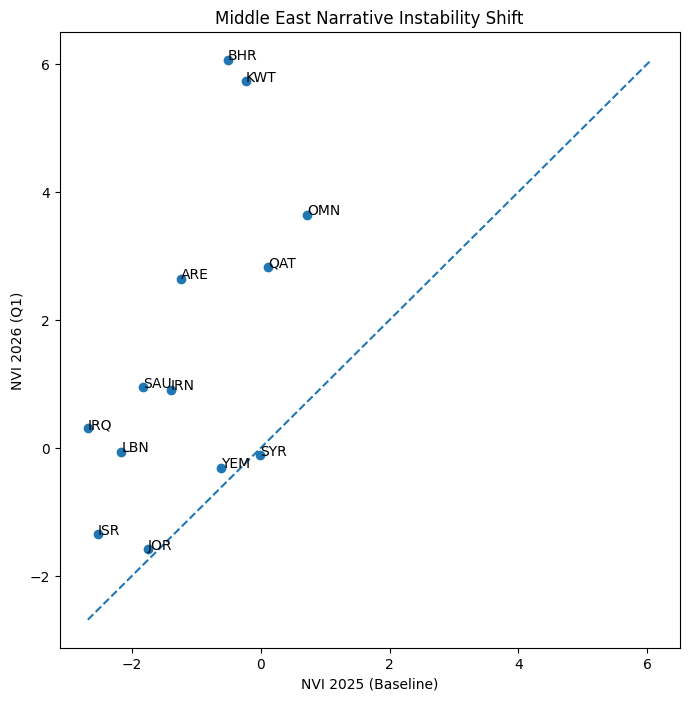

In [16]:
plt.figure(figsize=(8,8))

plt.scatter(me_df["NVI_2025"], me_df["NVI_2026"])

# diagonal line
min_val = min(me_df["NVI_2025"].min(), me_df["NVI_2026"].min())
max_val = max(me_df["NVI_2025"].max(), me_df["NVI_2026"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# label countries
for _, row in me_df.iterrows():
    plt.text(row["NVI_2025"], row["NVI_2026"], row["country"])

plt.xlabel("NVI 2025 (Baseline)")
plt.ylabel("NVI 2026 (Q1)")
plt.title("Middle East Narrative Instability Shift")

plt.show()

### 11.3 Delta NVI by Country

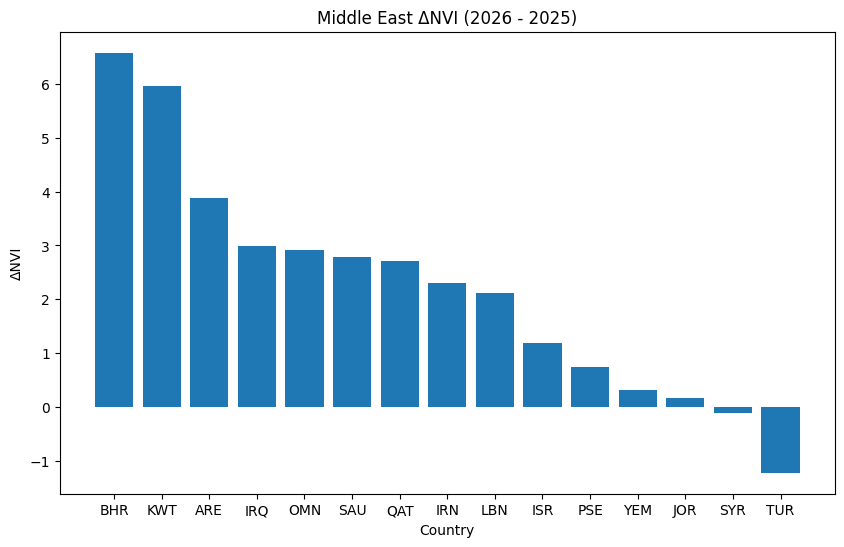

In [18]:
me_df = me_df.sort_values("delta_NVI", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(me_df["country"], me_df["delta_NVI"])

plt.title("Middle East ΔNVI (2026 - 2025)")
plt.xlabel("Country")
plt.ylabel("ΔNVI")

plt.show()

In [48]:
me_table = merged[merged["country"].isin(middle_east_gulf)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

me_table

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026
10,BHR,-0.513215,6.067970,6.581186,Moderate,Shock
14,KWT,-0.238648,5.732120,5.970768,Moderate,Shock
22,ARE,-1.235715,2.645284,3.880999,Moderate,Shock
147,IRQ,-2.688478,0.302389,2.990867,Stable,Moderate
96,OMN,0.723203,3.646784,2.923581,Moderate,Shock
19,SAU,-1.831909,0.949078,2.780987,Stable,Moderate
169,QAT,0.113307,2.825710,2.712403,Moderate,Shock
199,IRN,-1.395491,0.910231,2.305722,Moderate,Moderate
92,LBN,-2.167016,-0.059593,2.107423,Stable,Moderate
162,ISR,-2.531581,-1.353440,1.178141,Stable,Moderate


The Middle East and Gulf table shows a clear concentration of positive NVI shifts among **Gulf countries**. **BHR**, **KWT**, **ARE**, **OMN**, and **QAT** move from `Moderate` to `Shock`, while **SAU** moves from `Stable` to `Moderate`.

This suggests that the early-2026 period produced a substantial increase in narrative volatility for several Gulf countries when evaluated against the 2025 baseline. The strongest increases are observed for **BHR** and **KWT**.

Other countries in the broader regional environment, such as **IRQ**, **IRN**, **LBN**, and **ISR**, also show positive `delta_NVI`, but their regime transitions are generally less extreme than the Gulf cases.

### 11.4 Component-Level Delta Decomposition

To better understand why NVI changed between 2025 and 2026, the change in each standardized component is decomposed separately.

This helps identify whether a country's increase in NVI is mainly driven by **tone volatility**, **Goldstein volatility**, or **entropy volatility**.

In [49]:
# Component-level changes between 2025 and 2026
merged["delta_z_tone"] = merged["z_tone_2026"] - merged["z_tone_2025"]
merged["delta_z_gold"] = merged["z_gold_2026"] - merged["z_gold_2025"]
merged["delta_z_entropy"] = merged["z_entropy_2026"] - merged["z_entropy_2025"]

component_delta_cols = [
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy"
]

merged["dominant_delta_component"] = merged[component_delta_cols].idxmax(axis=1)

delta_decomposition = merged[[
    "country",
    "delta_NVI",
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy",
    "dominant_delta_component",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

delta_decomposition.head(20)

,country,delta_NVI,delta_z_tone,delta_z_gold,delta_z_entropy,dominant_delta_component,regime_2025,regime_2026
10,BHR,6.581186,2.407456,2.821071,1.352659,delta_z_gold,Moderate,Shock
14,KWT,5.970768,1.651851,3.968646,0.350270,delta_z_gold,Moderate,Shock
22,ARE,3.880999,1.641838,1.837744,0.401416,delta_z_gold,Moderate,Shock
147,IRQ,2.990867,0.911834,1.854649,0.224385,delta_z_gold,Stable,Moderate
96,OMN,2.923581,1.346600,1.043425,0.533556,delta_z_tone,Moderate,Shock
19,SAU,2.780987,1.333853,1.135778,0.311357,delta_z_tone,Stable,Moderate
169,QAT,2.712403,0.543367,1.465321,0.703715,delta_z_gold,Moderate,Shock
166,MHL,2.593974,0.556473,1.790208,0.247294,delta_z_gold,Shock,Shock
44,AFG,2.381391,0.747019,1.376882,0.257490,delta_z_gold,Moderate,Shock
199,IRN,2.305722,0.892667,1.147132,0.265923,delta_z_gold,Moderate,Moderate


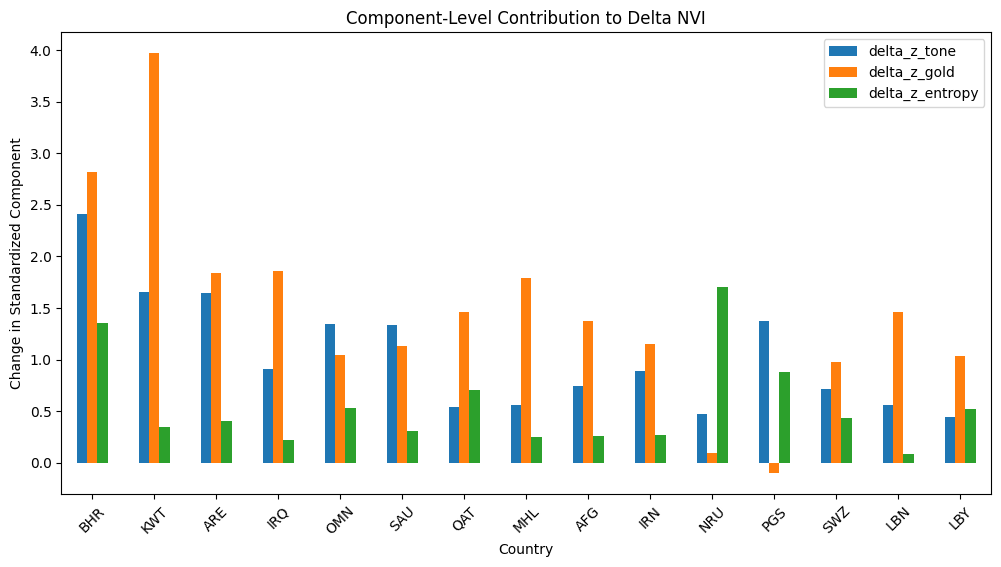

In [50]:
top_delta_components = delta_decomposition.head(15).set_index("country")[
    ["delta_z_tone", "delta_z_gold", "delta_z_entropy"]
]

top_delta_components.plot(kind="bar", figsize=(12, 6))

plt.title("Component-Level Contribution to Delta NVI")
plt.xlabel("Country")
plt.ylabel("Change in Standardized Component")
plt.xticks(rotation=45)
plt.show()

The component-level decomposition shows that the largest positive NVI shifts are mainly driven by increases in **Goldstein volatility** and **tone volatility**.

For several Gulf countries, including **BHR**, **KWT**, **ARE**, and **QAT**, the dominant increase comes from **Goldstein volatility**. This suggests stronger fluctuation in cooperation-conflict signals between 2025 and early 2026.

For **OMN** and **SAU**, the dominant increase is instead associated with **tone volatility**, suggesting stronger changes in the emotional tone of media narratives.

Overall, the 2026 increase is not driven by a single component for all countries. However, the results indicate that **Goldstein volatility plays a central role in the largest Gulf-related NVI shifts**.

### 11.5 Conflict-Context Interpretation

The largest positive NVI shifts are concentrated in several **Gulf countries**, including **Bahrain**, **Kuwait**, the **United Arab Emirates**, **Oman**, **Saudi Arabia**, and **Qatar**. This pattern is important because the early-2026 period overlaps with a major escalation involving Iran, Israel, and Gulf countries.

External conflict reporting from **ACLED** describes that, during March 2026, Iran attacked all Gulf Cooperation Council countries for the first time, including Bahrain, Kuwait, Oman, Qatar, Saudi Arabia, and the UAE (ACLED, 2026a). ACLED’s April 2026 Middle East overview also reports later escalation affecting Gulf industrial and energy-related targets, including facilities in Bahrain and the UAE (ACLED, 2026b).

Therefore, the increase in NVI among Gulf countries can be interpreted as **descriptively consistent** with regional escalation during early 2026. However, this should **not** be treated as causal proof. The NVI measures changes in **narrative volatility**, not the direct physical impact or severity of conflict.

## 12. War-Relevant Regional Group Comparison

To interpret the 2025–2026 changes more clearly, countries are grouped into selected conflict-relevant regional sets. These groups are not formal statistical clusters; they are used for descriptive comparison.

The purpose is to examine whether countries directly or indirectly connected to major conflict environments show different NVI shifts.

In [51]:
war_group_map = {
    # Gulf countries affected by Iran-Gulf escalation
    "BHR": "Gulf",
    "KWT": "Gulf",
    "ARE": "Gulf",
    "OMN": "Gulf",
    "SAU": "Gulf",
    "QAT": "Gulf",

    # Iran-Israel core comparison
    "IRN": "Iran-Israel Core",
    "ISR": "Iran-Israel Core",

    # Levant / Gaza-related regional environment
    "PSE": "Levant / Gaza-related",
    "LBN": "Levant / Gaza-related",
    "SYR": "Levant / Gaza-related",
    "JOR": "Levant / Gaza-related",
    "IRQ": "Levant / Gaza-related",
    "YEM": "Levant / Gaza-related",

    # Ukraine-Russia war environment
    "UKR": "Ukraine-Russia",
    "RUS": "Ukraine-Russia",

    # Selected Africa conflict cases
    "SDN": "Africa conflict cases",
    "SSD": "Africa conflict cases",
    "TCD": "Africa conflict cases",
    "COD": "Africa conflict cases",
    "NGA": "Africa conflict cases",
    "MLI": "Africa conflict cases",
    "NER": "Africa conflict cases",
    "BFA": "Africa conflict cases"
}

merged["war_relevant_group"] = merged["country"].map(war_group_map).fillna("Other")

### 12.1 Group-Level Delta Summary

This section summarizes how NVI changed across selected conflict-relevant country groups.

The goal is to compare whether countries connected to specific conflict environments show different levels of change in narrative volatility between 2025 and early 2026. The comparison is descriptive and should not be interpreted as causal evidence.

In [52]:
# Create transition flags before group-level aggregation
merged["moved_to_shock_flag"] = (
    (merged["regime_2025"] != "Shock") & 
    (merged["regime_2026"] == "Shock")
)

merged["shock_2026_flag"] = merged["regime_2026"] == "Shock"

# Group-level summary
war_group_summary = merged.groupby("war_relevant_group").agg(
    country_count=("country", "count"),
    mean_delta_NVI=("delta_NVI", "mean"),
    median_delta_NVI=("delta_NVI", "median"),
    max_delta_NVI=("delta_NVI", "max"),
    shock_2026_count=("shock_2026_flag", "sum"),
    moved_to_shock=("moved_to_shock_flag", "sum")
).reset_index()

war_group_summary = war_group_summary.sort_values("mean_delta_NVI", ascending=False)

war_group_summary

,war_relevant_group,country_count,mean_delta_NVI,median_delta_NVI,max_delta_NVI,shock_2026_count,moved_to_shock
1,Gulf,6,4.141654,3.402290,6.581186,5,5
2,Iran-Israel Core,2,1.741932,1.741932,2.305722,0,0
3,Levant / Gaza-related,6,1.032664,0.520649,2.990867,0,0
4,Other,187,0.086349,0.038867,2.593974,57,8
0,Africa conflict cases,8,0.049366,0.230921,1.614415,1,1
5,Ukraine-Russia,2,-0.404406,-0.404406,-0.233592,0,0


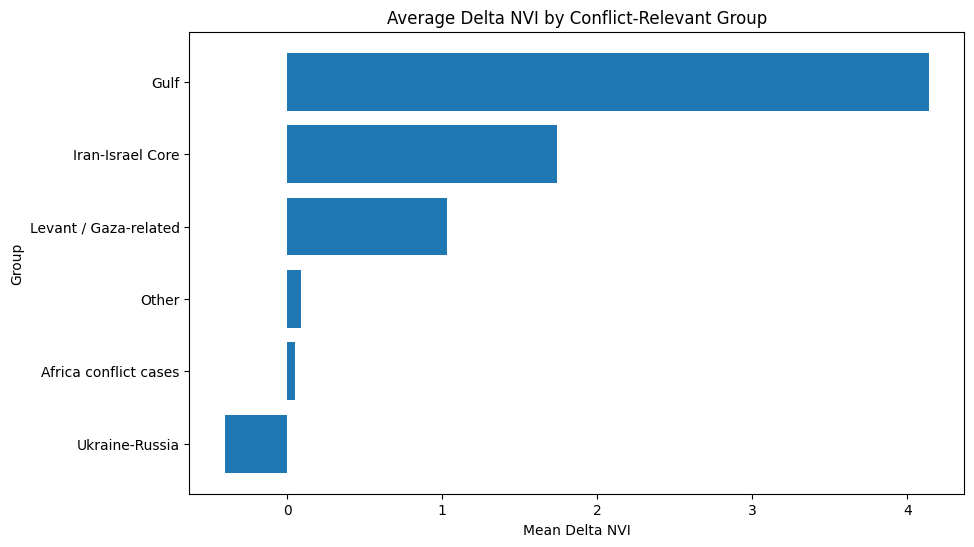

In [53]:
# Plot including all groups
plot_df = war_group_summary.sort_values("mean_delta_NVI", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["war_relevant_group"], plot_df["mean_delta_NVI"])

plt.title("Average Delta NVI by Conflict-Relevant Group")
plt.xlabel("Mean Delta NVI")
plt.ylabel("Group")
plt.show()

The group-level results show that the **Gulf group has by far the highest mean delta NVI**. Its average increase is substantially larger than the Iran-Israel Core, Levant/Gaza-related countries, Africa conflict cases, and the Ukraine-Russia group.

This is one of the strongest findings of the out-of-sample validation. It suggests that the 2026 increase in narrative volatility is especially concentrated among **Gulf countries**.

The **Iran-Israel Core** and **Levant/Gaza-related** groups also show positive average changes, but their increases are smaller than the Gulf group. The **Ukraine-Russia** group shows a negative mean delta NVI in this sample, suggesting that narrative volatility did not increase relative to the 2025 baseline under this framework.

The `Other` group is included as a broad reference category, but it should not be interpreted as a conflict-relevant group. It contains a large and heterogeneous set of countries that are not part of the selected conflict-focused groups.

These results should be interpreted **descriptively**. Group averages may be affected by the small number of countries in each group, differences in event coverage, and the fact that the 2026 data covers only the early part of the year.

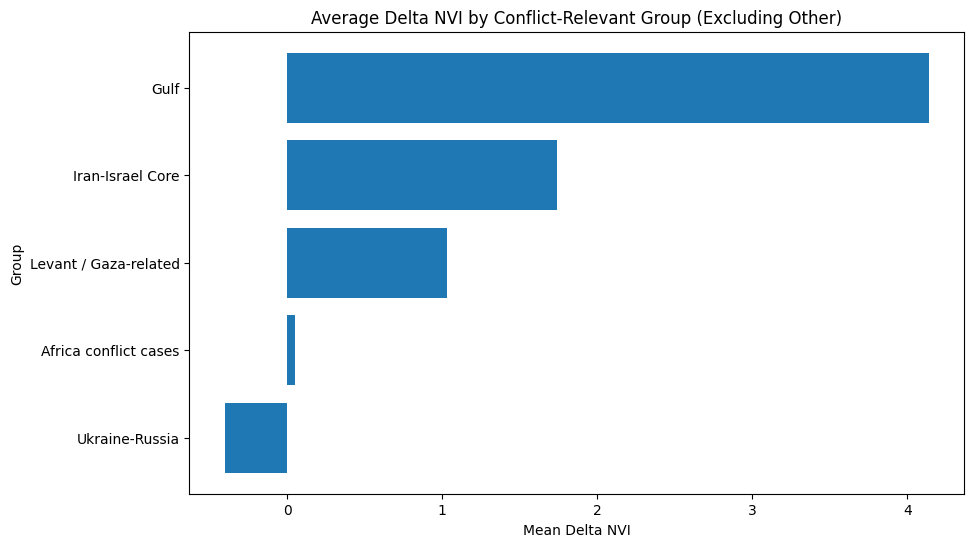

In [54]:
# Plot excluding the broad "Other" category
plot_df_no_other = war_group_summary[
    war_group_summary["war_relevant_group"] != "Other"
].sort_values("mean_delta_NVI", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df_no_other["war_relevant_group"],
    plot_df_no_other["mean_delta_NVI"]
)

plt.title("Average Delta NVI by Conflict-Relevant Group (Excluding Other)")
plt.xlabel("Mean Delta NVI")
plt.ylabel("Group")
plt.show()

The same comparison is also shown without the broad `Other` category, because this group contains a large and heterogeneous set of countries. Excluding it makes the selected conflict-relevant groups easier to compare.

This second plot makes the contrast clearer: the **Gulf group** shows the strongest increase in average NVI, while the **Iran-Israel Core** and **Levant/Gaza-related** groups show more moderate positive changes. The **Ukraine-Russia** group shows a negative average delta NVI in this sample.

This does not mean that the Ukraine-Russia war became unimportant. Rather, it means that under this NVI framework and the available early-2026 data, the selected narrative volatility indicators did not increase relative to the 2025 baseline for that group.

### 12.2 Gulf Countries: Focused Interpretation

The Gulf countries show the strongest positive NVI shifts in the current results. Bahrain, Kuwait, the United Arab Emirates, Oman, Saudi Arabia, and Qatar all show increases in NVI from 2025 to 2026, with several countries moving into the **Shock** regime.

This is one of the clearest findings of the out-of-sample validation notebook.

In [55]:
gulf_countries = ["BHR", "KWT", "ARE", "OMN", "SAU", "QAT"]

gulf_table = merged[merged["country"].isin(gulf_countries)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "delta_z_tone",
    "delta_z_gold",
    "delta_z_entropy",
    "dominant_delta_component",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

gulf_table

,country,NVI_2025,NVI_2026,delta_NVI,delta_z_tone,delta_z_gold,delta_z_entropy,dominant_delta_component,regime_2025,regime_2026
10,BHR,-0.513215,6.067970,6.581186,2.407456,2.821071,1.352659,delta_z_gold,Moderate,Shock
14,KWT,-0.238648,5.732120,5.970768,1.651851,3.968646,0.350270,delta_z_gold,Moderate,Shock
22,ARE,-1.235715,2.645284,3.880999,1.641838,1.837744,0.401416,delta_z_gold,Moderate,Shock
96,OMN,0.723203,3.646784,2.923581,1.346600,1.043425,0.533556,delta_z_tone,Moderate,Shock
19,SAU,-1.831909,0.949078,2.780987,1.333853,1.135778,0.311357,delta_z_tone,Stable,Moderate
169,QAT,0.113307,2.825710,2.712403,0.543367,1.465321,0.703715,delta_z_gold,Moderate,Shock


The Gulf-focused table confirms that all six Gulf countries in the selected group experienced **positive delta NVI** values.

Five of the six countries, **BHR**, **KWT**, **ARE**, **OMN**, and **QAT**, move into the **Shock** regime in 2026. **SAU** also shows a strong positive increase but moves from `Stable` to `Moderate` rather than `Shock`.

The component decomposition shows that the increases are mainly associated with **Goldstein volatility** for BHR, KWT, ARE, and QAT, while **tone volatility** is dominant for OMN and SAU.

This makes the Gulf group the clearest regional signal in the out-of-sample validation notebook.

### 12.3 Iran–Israel and Levant Comparison

This comparison examines whether the Iran-Israel core and surrounding Levant/Gaza-related countries show similar or different NVI shifts.

In [27]:
levant_group = [
    "IRN", "ISR", "PSE", "LBN", "SYR", "JOR", "IRQ", "YEM"
]

levant_table = merged[merged["country"].isin(levant_group)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

levant_table

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026
43,IRQ,-2.688478,0.302389,2.990867,Stable,Moderate
84,IRN,-1.395491,0.910231,2.305722,Moderate,Moderate
118,LBN,-2.167016,-0.059593,2.107423,Stable,Moderate
29,ISR,-2.531581,-1.353440,1.178141,Stable,Moderate
92,PSE,-2.401550,-1.669835,0.731715,Stable,Moderate
210,YEM,-0.618503,-0.308921,0.309582,Moderate,Moderate
150,JOR,-1.754275,-1.585589,0.168687,Stable,Moderate
208,SYR,-0.006359,-0.118648,-0.112289,Moderate,Moderate


The Iran–Israel and Levant comparison shows that most countries in this group experienced **positive delta NVI**, although none moved into the Shock regime.

The largest increases are observed for **IRQ**, **IRN**, and **LBN**. Several countries, including **IRQ**, **LBN**, **ISR**, **PSE**, and **JOR**, move from `Stable` to `Moderate`.

This suggests that the broader regional environment experienced an increase in narrative volatility, but the magnitude of change was generally smaller than in the Gulf group.

The result is also methodologically important: politically central conflict actors such as **IRN** and **ISR** do not necessarily have the largest NVI increases. The NVI measures **volatility in narrative indicators**, not geopolitical importance or conflict intensity.

### 12.4 Africa Conflict Cases

This section checks selected African conflict cases to see whether early 2026 conflict dynamics are reflected in NVI changes.

In [28]:
africa_conflict_cases = ["SDN", "SSD", "TCD", "COD", "NGA", "MLI", "NER", "BFA"]

africa_conflict_table = merged[merged["country"].isin(africa_conflict_cases)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

africa_conflict_table

,country,NVI_2025,NVI_2026,delta_NVI,regime_2025,regime_2026
34,MLI,-0.116840,1.497574,1.614415,Moderate,Shock
197,NER,-1.277296,0.320319,1.597615,Moderate,Moderate
9,BFA,-0.638511,0.373511,1.012022,Moderate,Moderate
186,SDN,-2.150241,-1.813403,0.336838,Stable,Stable
91,NGA,-2.854478,-2.729474,0.125003,Stable,Stable
77,TCD,-0.956914,-1.654367,-0.697453,Moderate,Moderate
207,SSD,-0.541221,-1.848295,-1.307073,Moderate,Stable
108,COD,2.293372,0.006936,-2.286435,Shock,Moderate


The selected Africa conflict cases show mixed NVI changes. **MLI**, **NER**, and **BFA** show positive delta NVI values, with **MLI** moving from `Moderate` to `Shock`. This is consistent with the relevance of Sahel conflict dynamics for narrative volatility.

However, not all selected African conflict cases show increases. **SSD** and **COD** show negative delta NVI values, and **COD** moves from `Shock` to `Moderate`. This suggests that conflict relevance does not automatically translate into higher NVI.

The mixed results indicate that the NVI captures changes in **narrative volatility**, not conflict presence alone. Differences in media coverage, event volume, and the timing of conflict dynamics may affect the observed NVI shifts.

## 13. Discussion and Interpretation

The out-of-sample validation shows how the NVI framework can be applied beyond the baseline period. By using **2025 normalization parameters** for both 2025 and 2026, the analysis preserves a consistent scale across years.

The strongest empirical pattern in this notebook is the concentration of positive NVI shifts among **Gulf countries**. Bahrain, Kuwait, the United Arab Emirates, Oman, Saudi Arabia, and Qatar all show positive `delta_NVI` values, and five of these countries move into the **Shock** regime in 2026.

This pattern is descriptively consistent with early-2026 conflict reporting on the Iran-Israel-Gulf escalation. However, the analysis does **not** claim that the conflict directly caused the NVI shifts. Instead, it shows that the NVI framework captures a narrative volatility increase in countries that were also highly relevant to the regional escalation.

The Iran-Israel and Levant group also shows generally positive NVI changes, although the increases are smaller than in the Gulf group and none of the selected countries move into the Shock regime. This suggests that politically central conflict actors do not necessarily show the largest NVI increases.

The selected African conflict cases show mixed results. Mali, Niger, and Burkina Faso show positive changes, while South Sudan and the Democratic Republic of the Congo show decreases. This reinforces the interpretation that the NVI measures **changes in narrative volatility**, not the mere presence of conflict.

Several limitations should be considered. The 2026 period covers only the **first three months of the year**, so the results should be interpreted as an early-period comparison rather than a full-year validation. In addition, countries with lower event coverage may show larger volatility changes because smaller changes in the underlying indicators can have a stronger effect on rolling volatility.

## References

ACLED. (2026a). *Middle East Special Issue: March 2026*. Armed Conflict Location & Event Data Project. https://acleddata.com/update/middle-east-special-issue-march-2026

ACLED. (2026b). *Middle East Overview: April 2026*. Armed Conflict Location & Event Data Project. https://acleddata.com/update/middle-east-overview-april-2026

## 14. Summary

This notebook evaluated the NVI framework in an **out-of-sample setting**. The analysis used **2025 as the baseline period** and applied the same normalization parameters to **early-2026 observations**.

Rolling volatility was recomputed across the full timeline before extracting yearly snapshots, ensuring that the 2026 values retained historical context. The recalculated 2025 NVI was validated against the original NVI table, and the near-zero difference confirmed that the pipeline was internally consistent.

The comparison between 2025 and 2026 identified changes in narrative volatility using `delta_NVI` and regime transitions. The clearest result is the concentration of large positive NVI shifts in the **Gulf countries**. Bahrain, Kuwait, the United Arab Emirates, Oman, Saudi Arabia, and Qatar all show increased NVI values, and five of these countries move into the **Shock** regime.

The component-level decomposition shows that these increases are mainly associated with **Goldstein volatility** and **tone volatility**, suggesting changes in both cooperation-conflict signals and media tone.

The Iran-Israel and Levant comparison shows positive but more moderate increases, while the selected African conflict cases show mixed results. These findings support the interpretation that NVI measures **narrative volatility**, not conflict intensity or geopolitical importance directly.

Overall, this notebook shows that the NVI can be extended beyond its baseline construction and used to evaluate changes in narrative volatility across time. However, because the 2026 data covers only part of the year, the results should be interpreted as an **early-2026 comparison** rather than a full-year validation.